# Import Libraries

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [161]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path,'AB_NYC_2019.csv'))
df.head()

Path to dataset files: /Users/badal/.cache/kagglehub/datasets/dgomonov/new-york-city-airbnb-open-data/versions/3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [163]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [164]:
df.shape

(48895, 16)

# Exploratory Data Analysis(EDA)

We explore the data in the standard order every ML Engineer follow
* Missing value
* Univariate analysis (one variable at a time - distributions, skewness)
* Bivariate analysis (relationship between features and the target)
* Correlation between numeric features
* Outlier inspection

**Missing Values**

In [165]:
missing = df.isna().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

**Target Variable -- room type**

In [166]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

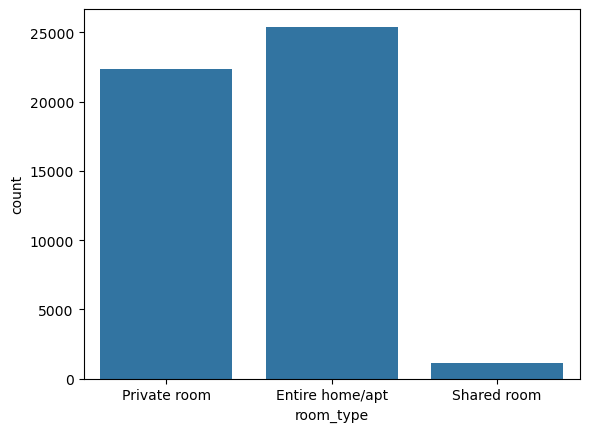

In [167]:
sns.countplot(data=df,x='room_type')

The classes are imbalanced -> shared room is small minority.

**Univariate Analysis** --Numerical Feature

In [168]:

numerical_cols =['price', 'minimum_nights', 'number_of_reviews','reviews_per_month',
       'calculated_host_listings_count', 'availability_365']


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

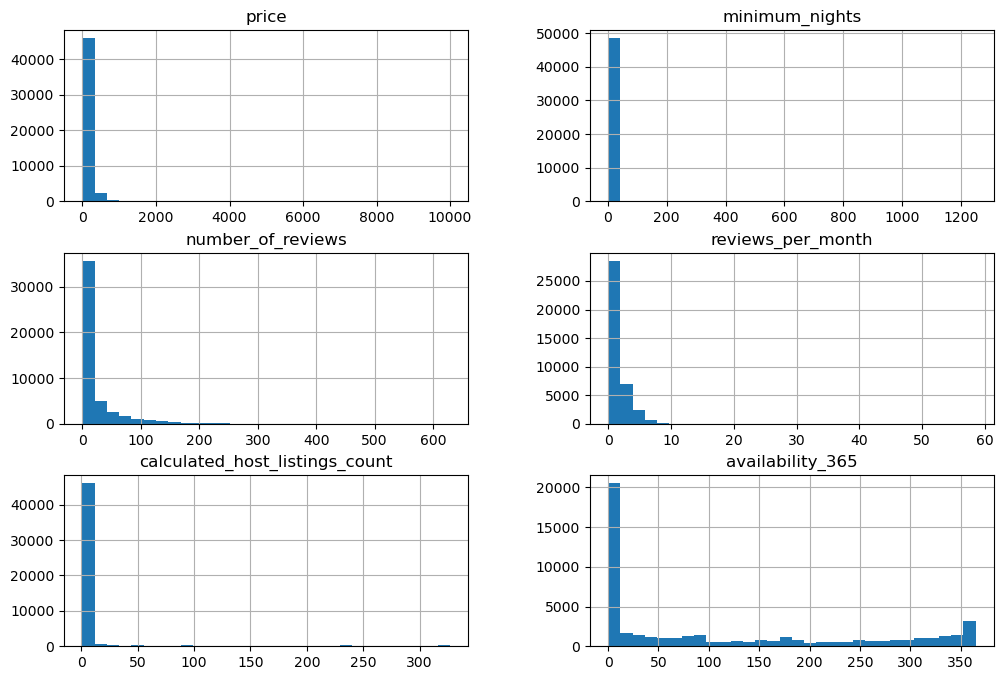

In [169]:
df[numerical_cols].hist(bins = 30,figsize=(12,8))

**Univariate Analysis** --Categorical Feature

In [170]:
categorical_col = df.select_dtypes(include=str).columns
categorical_col

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='str')

<Axes: xlabel='neighbourhood_group', ylabel='count'>

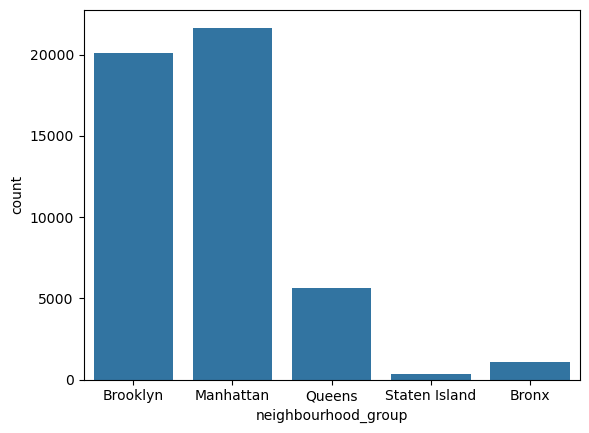

In [171]:
sns.countplot(data=df,x ='neighbourhood_group')

**Bivariate Analysis** - Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

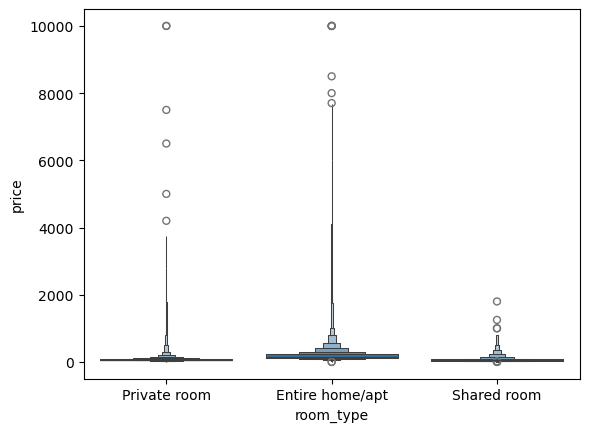

In [172]:
sns.boxenplot(x='room_type',y= 'price',data=df)

**Corelationship Between** Numeric features

<Axes: >

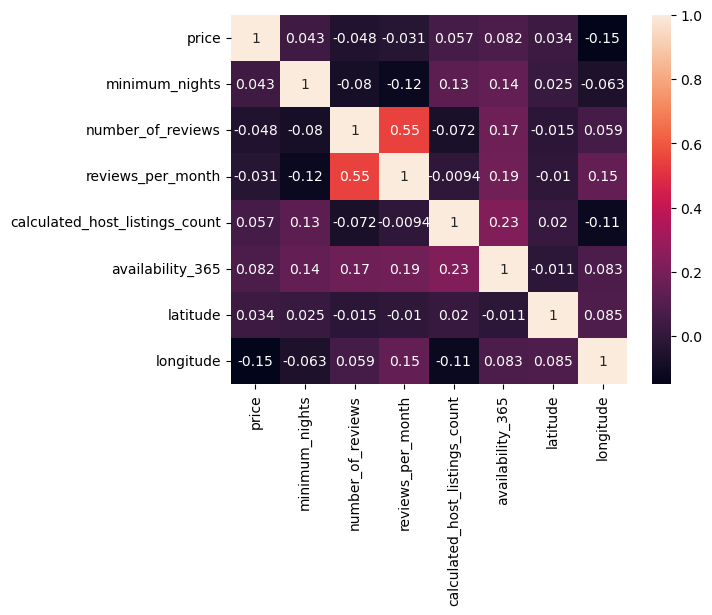

In [173]:
corr = df[numerical_cols + ['latitude','longitude']].corr()
sns.heatmap(corr,annot=True)

**Geographic Distribution** (Bonous Visual)

<Axes: xlabel='latitude', ylabel='longitude'>

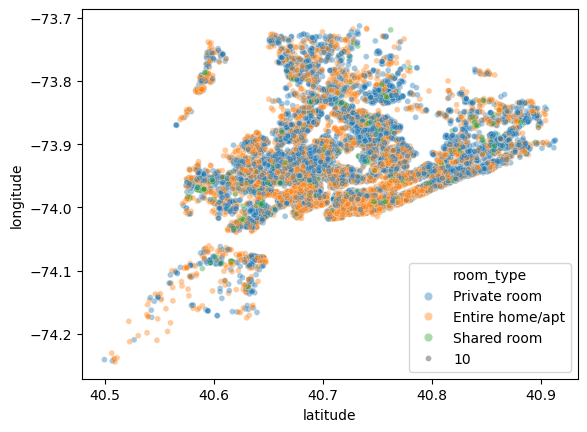

In [174]:
sns.scatterplot(x = 'latitude',y='longitude',data=df,hue='room_type',alpha =0.4,size=10)

# Data Cleaning & Feature Engineering
steps:
1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a tabular model (id, name, host_id, host_name, last_review).
2. Fill missing reviews_per_month with • (no reviews yet).
3. Cap extreme outliers in price and minimum nights using percentile clipping, so a handful of data-entry errors (e.g.
$10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (X) from the target (y).

In [175]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [176]:
# droping thoes column which don't contribiute
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name','last_review']) 
# No review yet -> Zero reviews pe month,not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [177]:
# Cap Extream removing outliers instead of deleting rows

price_cap = df_clean['price'].quantile(0.99)
night_cap = df_clean['minimum_nights'].quantile(0.99)
# print(price_cap)
# print(night_cap)
# df_clean = df_clean[df['price']<price_cap]
# df_clean = df_clean[df['minimum_nights']<night_cap]
df_clean['price'] = df_clean['price'].clip(upper =price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper = night_cap)


<Axes: xlabel='room_type', ylabel='price'>

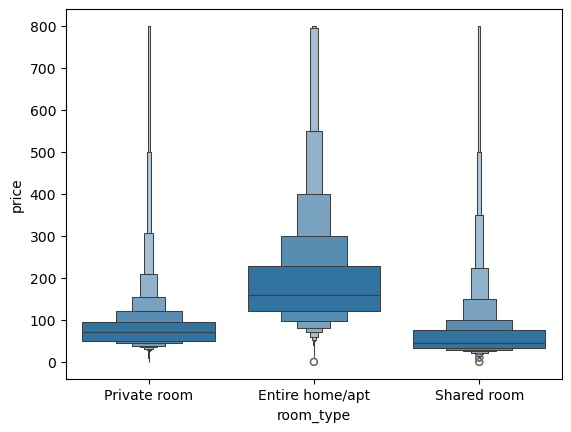

In [178]:
sns.boxenplot(x='room_type',y= 'price',data=df_clean)

In [179]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

In [180]:
print(X.shape)
print(y.shape)

(48895, 10)
(48895,)


# Train / Test Split
We hold out 20% of the data as a test set that is never touched during model selection or tuning - it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced

In [181]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=12,stratify=y)  
 

# Preprocessing: ColumnTransformer + Pipeline
Production ML code should never manually transform train/test data with separate lines - it's error-prone and leaks information. Instead we build a single, reusable ColumnTransformer :
* Numeric features → median imputation + standard scaling
* Categorical features → most-frequent imputation + one-hot encoding

This transformer will be the first step of every model pipeline below, so preprocessing is learned only on training data and applied consistently everywhere (no data leakage)

In [182]:
df_clean[numerical_cols].skew()

price                             2.776321
minimum_nights                    2.360347
number_of_reviews                 3.690635
reviews_per_month                 3.300723
calculated_host_listings_count    7.933174
availability_365                  0.763408
dtype: float64

In [183]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer # PowerTransformer  Handling skewness in data
from sklearn.compose import ColumnTransformer

In [184]:
numerical_cols =['latitude','longitude','price', 'minimum_nights', 'number_of_reviews','reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

In [185]:
categorical_col = ['neighbourhood_group','neighbourhood']

In [186]:
# 1.Pipeline -> For numerical columns
numeric_pipeline  = Pipeline(steps=[
    ("impute",SimpleImputer(strategy='median')),
    ('skewness',PowerTransformer(method='yeo-johnson')),
    ('scale',StandardScaler())
])

#2. Pipeline -> for categorical columns
categorical_pipeline = Pipeline(
    steps = [
        ("impute",SimpleImputer(strategy='most_frequent')),
        ("encode",OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output = False))
    ]
)

In [187]:
preproceesor = ColumnTransformer(
    transformers =[
        ('numerical',numeric_pipeline,numerical_cols),
        ('categorical',categorical_pipeline,categorical_col)
    ]
)

In [188]:
preproceesor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [189]:
preproceesor.fit_transform(X_train).shape
# preproceesor.transform(X_test)

(39116, 230)

# Trying Multiple Algorithms
We now compare several models, each wrapped in its own pipeline with the same preprocessor. We evaluate each with 3-fold stratified cross-validation on the training set (never touching the test set yet), so the comparison is fair and robust.

Models tried:

1. Logistic Regression - simple, interpretable linear baseline
2. Decision Tree — a single non-linear model, prone to overfitting
3. Random Forest - an ensemble of trees, usually a strong general-purpose model
4. Gradient Boosting - sequential ensemble, often the most accurate of the classics

In [190]:
import warnings
warnings.filterwarnings("ignore")

In [191]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import  mean_squared_log_error

In [192]:

models={
    "Logistic Regression": LogisticRegression(class_weight='balanced',random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced',random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    
}
for name ,model in models.items():
    pipe = Pipeline(steps=[
        ("preproceesor",preproceesor),
        ('classifier',model)
    ])
    accuracy = cross_validate(pipe,X_train,y_train,cv=3,scoring="accuracy")
    macro_f1 = cross_validate(pipe,X_train,y_train,cv=3,scoring="f1_macro")
    print(f"{name} -> accuracy:{accuracy['test_score'].mean():.3f}, F1:{macro_f1['test_score'].mean():.3f}")
   

Logistic Regression -> accuracy:0.729, F1:0.578
Decision Tree -> accuracy:0.787, F1:0.659
Random Forest -> accuracy:0.852, F1:0.717
Gradient Boosting -> accuracy:0.852, F1:0.703


# Hyperparameter Tuning
We pick the best-performing model from the comparison above (whichever one that turns out to be) and search over its key hyperparameters using RandomizedSearchCV (cheaper than an exhaustive grid search, while still exploring the space well). We keep
optimizing for macro-F1 since the classes are imbalanced.

In [193]:
from sklearn.model_selection import RandomizedSearchCV

best_pipe_line = Pipeline(
    steps = [
        ('preproceesor',preproceesor),
        ('classifier',RandomForestClassifier(class_weight='balanced'))
    ]
)

para_grid ={
    'classifier__n_estimators':[100,200,500,150,400,600],
    'classifier__criterion':['gini', 'entropy', 'log_loss'],
    'classifier__max_depth':[None, 5, 10, 20, 30],
    'classifier__max_features':['sqrt', 'log2'],
    'classifier__min_samples_leaf':[1, 2, 4, 8],
    'classifier__min_samples_split':[2, 5, 10, 20],
    'classifier__bootstrap':[True,False]
}

search = RandomizedSearchCV(
    estimator=best_pipe_line,
    param_distributions = para_grid,
    n_iter = 10,
    n_jobs = -1,
    cv = 3,
    scoring='f1_macro',
    random_state = 42
    )
search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__bootstrap': [True, False], 'classifier__criterion': ['gini', 'entropy', ...], 'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the vari

In [194]:
print(search.best_params_)
print(search.best_score_)

{'classifier__n_estimators': 400, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20, 'classifier__criterion': 'entropy', 'classifier__bootstrap': False}
0.7349092536845078


# Final Evaluation on the Test Set
<>
This is the only time we touch the held-out test set. It gives us an honest estimate of how the final tuned model would perform on completely unseen listings.

In [195]:
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score

In [196]:
# best_pipe_line = Pipeline(
#     steps = [
#         ('preproceesor',preproceesor),
#         ('classifier',RandomForestClassifier(class_weight='balanced' ,
#                                              n_estimators=400,
#                                              criterion='entropy',
#                                              max_depth=20,
#                                              min_samples_split=5,
#                                              min_samples_leaf=1,
#                                              max_features='sqrt',
#                                              bootstrap=False,
#                                              class_weight='balanced',
#                                              random_state=42))
#     ]
# )
best_pipe_line = search.best_estimator_

y_pred = best_pipe_line.predict(X_test)

In [197]:
print(confusion_matrix(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print('F1_Score',f1_score(y_test,y_pred , average='macro')) 

[[4539  534    9]
 [ 745 3652   68]
 [  18  111  103]]
Accuracy Score: 0.8481439820022497
F1_Score 0.7359430729206418


<Axes: >

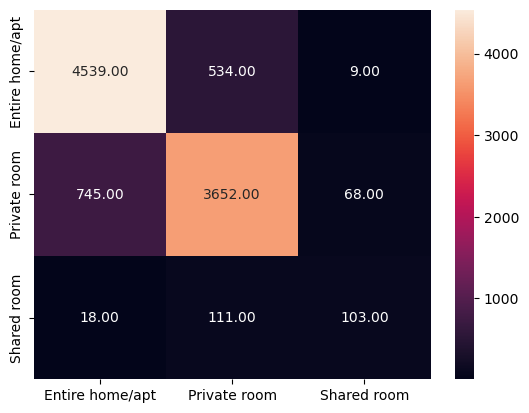

In [198]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='.2f',
    xticklabels=best_pipe_line.classes_,
    yticklabels=best_pipe_line.classes_
)

In [199]:
# from sklearn.model_selection import GridSearchCV

# best_pipe_line = Pipeline(
#     steps = [
#         ('preproceesor',preproceesor),
#         ('classifier',RandomForestClassifier(class_weight='balanced'))
#     ]
# )

# para_grid ={
#     'classifier__n_estimators':[100,200,500,150,400,600],
#     'classifier__criterion':['gini', 'entropy', 'log_loss'],
#     'classifier__max_depth':[None, 5, 10, 20, 30],
#     'classifier__max_features':['sqrt', 'log2'],
#     'classifier__min_samples_leaf':[1, 2, 4, 8],
#     'classifier__min_samples_split':[2, 5, 10, 20],
#     'classifier__bootstrap':[True,False]
# }


# search = GridSearchCV(
#     estimator=best_pipe_line,
#     param_grid=para_grid,
#     n_jobs=-1,
#     cv=3,
#     scoring='f1_macro'
# )
# search.fit(X_train,y_train)
# print(search.best_params_)
# print(search.best_score_)

# 11. Saving the Final Model Artifact
个
←
In production, the entire pipeline (preprocessing and model together) is serialized as a single artifact, so a new listing can be scored with one call no manual preprocessing required at inference time.

In [201]:
import joblib
joblib.dump(best_pipe_line,"model_pipeline.pkl")

['model_pipeline.pkl']

In [202]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [205]:
y_test.unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str